In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 01 — Rolling Window Setup

Partitions the processed Homesite dataset into chronological time steps and enumerates all valid (Model A, Model B) window pairs for the rolling-retraining experiment.

**Input:** `data/processed/` (from notebook 00)  
**Output:** `data/windows/window_config.json`

---

**Framework recap (§3.1):**
- Data partitioned into time steps D_{t1}, …, D_{tK} (one per calendar month).
- Training window: W_k = D_{t_{k-L+1}} ∪ … ∪ D_{t_k}  (fixed length L).
- Model A trained on W_k, Model B on W_{k+s}.
- Common evaluation slice: E_{A,B} = D_{t_{k+s+1}} ∪ … ∪ D_{t_{k+s+h}}.

**Parameters used:**
| Parameter | Value | Meaning |
|-----------|-------|---------|
| L | 8 | training window length (months) |
| S | 3 | step between Model A and Model B windows (months) |
| H | 3 | evaluation horizon (months) |
| R | 2 | replicas per window (used by nb 02) |
| K_FRAC | 0.10 | top fraction of eval instances flagged (by max replica-averaged probability of either model) |
| PAIR_STRIDE | 4 | spacing between candidate k values when enumerating pairs |

**Notes vs. Shoppers reference**
- Time unit is **month** (Shoppers uses week) because the Homesite span is ~28 months — a finer granularity would balloon compute without obvious benefit.
- `S=3` (vs. Shoppers' `S=2`) reduces A/B training-window overlap from 75% to 62.5%, giving the dynamics more room to differ between consecutive models.
- `PAIR_STRIDE=4` keeps the experiment to **4 pairs** (compute-bounded). Stride=1 would yield ~13 pairs.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Homesite_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'
WIN_DIR.mkdir(parents=True, exist_ok=True)  # create the output directory if it does not exist yet

# ── Experiment parameters ────────────────────────────────────────────────
L = 8           # training window length (time steps = months)
S = 3           # step between Model A and Model B windows
H = 3           # evaluation horizon (time steps)
R = 2           # replicas per window
K_FRAC = 0.10   # top-K fraction of eval instances to flag (by max(p_hat_A, p_hat_B))
PAIR_STRIDE = 4 # only every PAIR_STRIDE-th candidate k is materialised as a pair

print(f'Parameters: L={L}, S={S}, H={H}, R={R}, K_FRAC={K_FRAC}, PAIR_STRIDE={PAIR_STRIDE}')

Parameters: L=8, S=3, H=3, R=2, K_FRAC=0.1, PAIR_STRIDE=4


## 1. Load processed data

In [3]:
X    = pd.read_parquet(PROC_DIR / 'X.parquet')
Y    = np.load(PROC_DIR / 'Y.npy')
meta = pd.read_parquet(PROC_DIR / 'meta.parquet')

# reset_index gives a clean 0-based integer index; storing it as 'row_idx'
# keeps a stable positional reference so rows can be located with .iloc on
# X and Y even after groupby / merge operations reshape the DataFrame.
meta = meta.reset_index(drop=True)
meta['row_idx'] = meta.index

print(f'X: {X.shape}, Y: {Y.shape}')
print(f'Date range: {meta["quote_date"].min()} → {meta["quote_date"].max()}')

assert len(X) == len(Y) == len(meta), 'X, Y, and meta have inconsistent lengths.'
assert 'quote_date' in meta.columns, 'meta.parquet must contain a quote_date column.'
assert pd.api.types.is_datetime64_any_dtype(meta['quote_date']), 'quote_date must be datetime-like.'
assert not meta['quote_date'].isna().any(), 'quote_date contains missing values.'
assert meta['quote_date'].is_monotonic_increasing, (
    'quote_date is not monotonic non-decreasing; preprocessing should have sorted by it.'
)

X: (260753, 428), Y: (260753,)
Date range: 2013-01-01 00:00:00 → 2015-05-18 00:00:00


## 2. Define time steps (calendar months)

Quotes per calendar month:
month
2013-01-01     7195
2013-02-01     6744
2013-03-01     7493
2013-04-01     8833
2013-05-01     9413
2013-06-01     9798
2013-07-01    11241
2013-08-01    11272
2013-09-01    10245
2013-10-01    10148
2013-11-01     6336
2013-12-01     5740
2014-01-01    11270
2014-02-01     9909
2014-03-01    12008
2014-04-01     9585
2014-05-01     9124
2014-06-01    10091
2014-07-01     9542
2014-08-01     8274
2014-09-01     8067
2014-10-01     7860
2014-11-01     7432
2014-12-01     6945
2015-01-01     9755
2015-02-01     7897
2015-03-01    12241
2015-04-01    10205
2015-05-01     6090


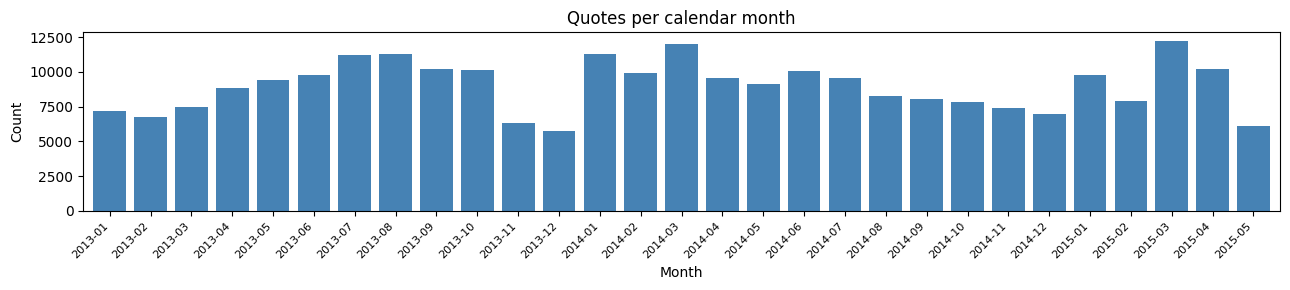


Quotes and conversion rate per month:
                n  positives  pos_rate
month                                 
2013-01-01   7195       1365    0.1897
2013-02-01   6744       1370    0.2031
2013-03-01   7493       1596    0.2130
2013-04-01   8833       1884    0.2133
2013-05-01   9413       1980    0.2103
2013-06-01   9798       1951    0.1991
2013-07-01  11241       2219    0.1974
2013-08-01  11272       2211    0.1961
2013-09-01  10245       2013    0.1965
2013-10-01  10148       2165    0.2133
2013-11-01   6336       1335    0.2107
2013-12-01   5740       1254    0.2185
2014-01-01  11270       1916    0.1700
2014-02-01   9909       1689    0.1705
2014-03-01  12008       2095    0.1745
2014-04-01   9585       1751    0.1827
2014-05-01   9124       1848    0.2025
2014-06-01  10091       1853    0.1836
2014-07-01   9542       1659    0.1739
2014-08-01   8274       1387    0.1676
2014-09-01   8067       1310    0.1624
2014-10-01   7860       1348    0.1715
2014-11-01   7432       1

In [4]:
# dt.to_period('M') maps each date to its calendar-month period;
# .dt.to_timestamp() converts that period back to the first-of-month
# anchor so all rows in the same calendar month share an identical 'month' value.
meta['month'] = meta['quote_date'].dt.to_period('M').dt.to_timestamp()

# Count quotes per month to inspect how the data is distributed over time.
# Highly uneven counts can affect training stability for some windows.
month_counts = meta.groupby('month').size().sort_index()
print('Quotes per calendar month:')
print(month_counts.to_string())

fig, ax = plt.subplots(figsize=(13, 3))
month_counts.plot(ax=ax, kind='bar', color='steelblue', width=0.8)
ax.set_title('Quotes per calendar month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_xticklabels([m.strftime('%Y-%m') for m in month_counts.index], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(WIN_DIR / 'quotes_per_month.png', dpi=120)
plt.show()

# Per-month target summary — useful for spotting drift in the base rate before any modelling.
month_target_summary = (
    meta.assign(y=Y)
        .groupby('month')
        .agg(n=('y', 'size'), positives=('y', 'sum'), pos_rate=('y', 'mean'))
        .sort_index()
)
print('\nQuotes and conversion rate per month:')
print(month_target_summary.to_string(float_format=lambda x: f'{x:.4f}'))

In [5]:
# Sorting gives the canonical temporal ordering t_1 … t_K used throughout the experiment.
# All step indices below are 0-based (t_1 → 0, t_K → K−1).
time_steps = sorted(month_counts.index.tolist())
K = len(time_steps)
print(f'K = {K} time steps')
for i, ts in enumerate(time_steps):
    n = month_counts[ts]
    print(f'  t_{i+1:>2d}: {ts.strftime("%Y-%m")}  ({n:,} quotes)')

K = 29 time steps
  t_ 1: 2013-01  (7,195 quotes)
  t_ 2: 2013-02  (6,744 quotes)
  t_ 3: 2013-03  (7,493 quotes)
  t_ 4: 2013-04  (8,833 quotes)
  t_ 5: 2013-05  (9,413 quotes)
  t_ 6: 2013-06  (9,798 quotes)
  t_ 7: 2013-07  (11,241 quotes)
  t_ 8: 2013-08  (11,272 quotes)
  t_ 9: 2013-09  (10,245 quotes)
  t_10: 2013-10  (10,148 quotes)
  t_11: 2013-11  (6,336 quotes)
  t_12: 2013-12  (5,740 quotes)
  t_13: 2014-01  (11,270 quotes)
  t_14: 2014-02  (9,909 quotes)
  t_15: 2014-03  (12,008 quotes)
  t_16: 2014-04  (9,585 quotes)
  t_17: 2014-05  (9,124 quotes)
  t_18: 2014-06  (10,091 quotes)
  t_19: 2014-07  (9,542 quotes)
  t_20: 2014-08  (8,274 quotes)
  t_21: 2014-09  (8,067 quotes)
  t_22: 2014-10  (7,860 quotes)
  t_23: 2014-11  (7,432 quotes)
  t_24: 2014-12  (6,945 quotes)
  t_25: 2015-01  (9,755 quotes)
  t_26: 2015-02  (7,897 quotes)
  t_27: 2015-03  (12,241 quotes)
  t_28: 2015-04  (10,205 quotes)
  t_29: 2015-05  (6,090 quotes)


In [6]:
# If certain months are very sparse (< 50 quotes), a single time step may be
# unreliable for training/evaluation. Switch to a coarser granularity if so.
MIN_PER_STEP = 50  # minimum quotes required to treat a month as its own time step
sparse_months = [ts for ts, n in month_counts.items() if n < MIN_PER_STEP]
if sparse_months:
    print(f'WARNING: {len(sparse_months)} month(s) have < {MIN_PER_STEP} quotes: {sparse_months}')
    print('Consider switching to a coarser granularity (e.g. quarterly).')
else:
    print('All months have sufficient quotes.')

# Lookup dict from month timestamp → 0-based integer step index.
# Mapping it onto meta['step'] allows every row to be addressed by its position
# in the temporal sequence rather than a calendar date.
month_to_step = {m: i for i, m in enumerate(time_steps)}
meta['step'] = meta['month'].map(month_to_step)

All months have sufficient quotes.


## 3. Enumerate valid window pairs

A pair (A, B) is valid when:
- k ≥ L − 1  (enough history for training window A)
- k + S + H ≤ K − 1  (evaluation slice fits within the data)

where k is the last time step of window A (0-based). The `PAIR_STRIDE` parameter then keeps only every PAIR_STRIDE-th candidate k, so the materialised pairs are spread across the full temporal range while the downstream compute (notebooks 02–04) stays bounded.

In [7]:
def get_indices(step_set: set) -> list:
    """Row indices for the given set of time-step indices, sorted chronologically.

    Sorting by quote_date ensures that TimeSeriesSplit in notebooks 02 / 02b
    sees rows in temporal order. row_idx is used as a deterministic tiebreaker
    for quotes on the same date.
    """
    return (meta[meta['step'].isin(step_set)]
            .sort_values(['quote_date', 'row_idx'])['row_idx']
            .tolist())


pairs = []

# Iterate over candidate last training step k for Model A, in PAIR_STRIDE jumps.
# Two constraints must both hold:
#   (1) k >= L - 1  →  enough prior steps to fill the L-step training window
#   (2) eval_end = k + S + H < K  →  the evaluation slice fits within the dataset
#
# With K=29, L=8, S=3, H=3, PAIR_STRIDE=4: valid k values are 7, 11, 15, 19 → 4 pairs.
for k in range(L - 1, K, PAIR_STRIDE):       # k = last step of window A (0-based)
    k_b = k + S                              # last step of window B (shifted S steps forward)
    eval_start = k_b + 1                     # first evaluation step (immediately after B's window)
    eval_end   = k_b + H                     # last evaluation step (H steps after eval_start - 1)

    if eval_end >= K:
        break                                # not enough future data for a complete evaluation slice

    # Time-step sets
    steps_A    = set(range(k - L + 1, k + 1))         # W_k:     L steps ending at k
    steps_B    = set(range(k_b - L + 1, k_b + 1))     # W_{k+s}: L steps ending at k+s
    steps_eval = set(range(eval_start, eval_end + 1)) # E_{A,B}: H steps starting after B

    # Row index lists — used directly as positional selectors on X and Y
    idx_A    = get_indices(steps_A)
    idx_B    = get_indices(steps_B)
    idx_eval = get_indices(steps_eval)

    if len(idx_eval) == 0:
        print(f'Skipping pair k={k}: empty evaluation slice')
        continue

    pairs.append({
        'pair_id':           len(pairs),
        'k':                 k,
        'k_b':               k_b,
        'step_label_A':      time_steps[k].strftime('%Y-%m'),
        'step_label_B':      time_steps[k_b].strftime('%Y-%m'),
        'eval_start_label':  time_steps[eval_start].strftime('%Y-%m'),
        'eval_end_label':    time_steps[eval_end].strftime('%Y-%m'),
        'steps_A':           sorted(steps_A),
        'steps_B':           sorted(steps_B),
        'steps_eval':        sorted(steps_eval),
        'idx_A':             idx_A,
        'idx_B':             idx_B,
        'idx_eval':          idx_eval,
        'n_train_A':         len(idx_A),
        'n_train_B':         len(idx_B),
        'n_eval':            len(idx_eval),
    })

print(f'\nTotal valid window pairs: {len(pairs)}')

# Verify step-sorted chronological order of each stored index list.
# Required for TimeSeriesSplit in notebooks 02/02b: rows from earlier steps must
# appear before rows from later steps so each CV fold is a valid out-of-time set.
for p in pairs:
    for label, idx_key in [('A', 'idx_A'), ('B', 'idx_B'), ('eval', 'idx_eval')]:
        steps_seq = meta.loc[p[idx_key], 'step'].values
        assert (steps_seq[:-1] <= steps_seq[1:]).all(), \
            f"Pair {p['pair_id']}: {label} indices are not step-sorted — TSCV ordering broken!"
print('Chronological-order assertions passed.')


Total valid window pairs: 4
Chronological-order assertions passed.


In [8]:
# Summary table: one row per valid pair.
# 'A_window' / 'B_window' show the last month of each model's training window
# (the full window spans the preceding L-1 months as well).
# 'eval_period' is the shared held-out slice used to compare both models.
summary = pd.DataFrame([{
    'pair_id':       p['pair_id'],
    'A_window':      f"{p['step_label_A']}",
    'B_window':      f"{p['step_label_B']}",
    'eval_period':   f"{p['eval_start_label']} → {p['eval_end_label']}",
    'n_train_A':     p['n_train_A'],
    'n_train_B':     p['n_train_B'],
    'n_eval':        p['n_eval'],
    'n_pos_A':       int(Y[p['idx_A']].sum()),
    'n_pos_B':       int(Y[p['idx_B']].sum()),
    'n_pos_eval':    int(Y[p['idx_eval']].sum()),
    'pos_rate_A':    float(Y[p['idx_A']].mean()),
    'pos_rate_B':    float(Y[p['idx_B']].mean()),
    'pos_rate_eval': float(Y[p['idx_eval']].mean()),
} for p in pairs])

with pd.option_context('display.width', 200, 'display.max_columns', None):
    print(summary.to_string(index=False))

# Inject the pos_rate / n_pos fields back into the pair dicts so they end up in the saved JSON.
# Notebook 04's drift analysis reads these directly without needing X/Y in memory.
for p, row in zip(pairs, summary.to_dict('records')):
    p['n_pos_A']       = row['n_pos_A']
    p['n_pos_B']       = row['n_pos_B']
    p['n_pos_eval']    = row['n_pos_eval']
    p['pos_rate_A']    = row['pos_rate_A']
    p['pos_rate_B']    = row['pos_rate_B']
    p['pos_rate_eval'] = row['pos_rate_eval']

empty_eval = summary[summary['n_eval'] == 0]
if not empty_eval.empty:
    print(f'\nWARNING: {len(empty_eval)} pair(s) with empty evaluation slice!')
else:
    print('\nAll evaluation slices are non-empty.')

# Class-balance assertion: every slice must contain both classes, otherwise the
# replica training, threshold-based flagging, and explanation extraction will all break.
for p in pairs:
    for label, idx_key in [('A', 'idx_A'), ('B', 'idx_B'), ('eval', 'idx_eval')]:
        y_slice = Y[p[idx_key]]
        assert len(np.unique(y_slice)) == 2, (
            f"Pair {p['pair_id']}: {label} slice contains only one class."
        )
print('Class-balance assertions passed.')

 pair_id A_window B_window       eval_period  n_train_A  n_train_B  n_eval  n_pos_A  n_pos_B  n_pos_eval  pos_rate_A  pos_rate_B  pos_rate_eval
       0  2013-08  2013-11 2013-12 → 2014-02      71989      77286   26919    14576    15758        4859    0.202475    0.203892       0.180504
       1  2013-12  2014-03 2014-04 → 2014-06      74193      76928   28800    15128    14678        5452    0.203901    0.190802       0.189306
       2  2014-04  2014-07 2014-08 → 2014-10      75241      77269   24201    14218    14065        4045    0.188966    0.182026       0.167142
       3  2014-08  2014-11 2014-12 → 2015-02      79803      69975   24597    14198    12563        4004    0.177913    0.179536       0.162784

All evaluation slices are non-empty.
Class-balance assertions passed.


## 4. Verify temporal separation within each pair

For a fair pairwise comparison, the common evaluation slice must chronologically follow both training windows and must not overlap with either training window.

In [9]:
for p in pairs:
    # Evaluation steps must not overlap with either training window —
    # overlap would constitute data leakage from the evaluation period into training.
    assert not set(p['steps_eval']) & set(p['steps_A']), f"Pair {p['pair_id']}: eval overlaps A!"
    assert not set(p['steps_eval']) & set(p['steps_B']), f"Pair {p['pair_id']}: eval overlaps B!"
    # The earliest evaluation step must come strictly after B's last training step,
    # guaranteeing temporal ordering: train A → train B → evaluate (no future peeking).
    assert min(p['steps_eval']) > max(p['steps_B']), f"Pair {p['pair_id']}: eval not after B!"

print('Non-overlap checks passed for all pairs.')

Non-overlap checks passed for all pairs.


## 5. Save window configuration

In [10]:
# The JSON captures everything needed to reproduce the experiment downstream:
#   'parameters' — scalar hyperparameters (L, S, H, R, K_FRAC, PAIR_STRIDE) and the
#                  ordered list of month labels that define the time axis.
#   'pairs'      — one entry per valid (A, B) pair, each containing:
#                    * integer step indices and human-readable date labels
#                    * pre-computed row index lists (idx_A, idx_B, idx_eval)
#                      that can be used directly with .iloc on X and Y in
#                      subsequent notebooks without re-running this setup
#                    * positive-class counts and rates per slice (consumed by nb 04).
config = {
    'parameters': {
        'L': L, 'S': S, 'H': H, 'R': R, 'K_FRAC': K_FRAC,
        'PAIR_STRIDE': PAIR_STRIDE,
        'K': K,
        'time_unit': 'month',
        'time_steps': [ts.strftime('%Y-%m') for ts in time_steps],
    },
    'pairs': pairs,
}

out_path = WIN_DIR / 'window_config.json'
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

size_kb = out_path.stat().st_size / 1024
print(f'Saved {out_path.name} ({size_kb:.0f} KB)')
print(f'{len(pairs)} window pairs, {K} time steps')

Saved window_config.json (10761 KB)
4 window pairs, 29 time steps


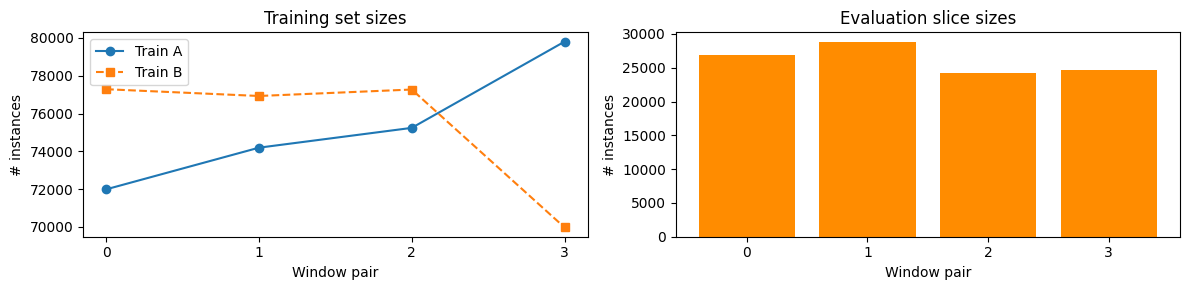

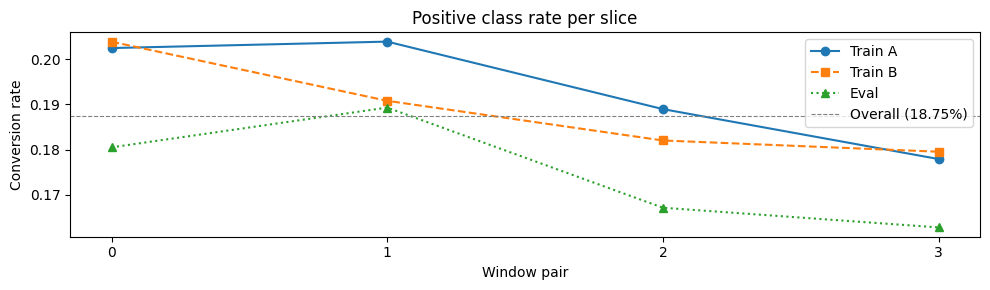

Done.


In [11]:
# Visual: training and evaluation set sizes over time.
# Left plot  — Train A vs Train B sample counts per pair.
#              B's window is offset by S steps, so it should overlap heavily
#              with A but include slightly newer data; sizes should be similar.
# Right plot — Evaluation slice size per pair.
#              Large drops would signal data gaps in the later months.
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

pair_ids = [p['pair_id'] for p in pairs]
axes[0].plot(pair_ids, [p['n_train_A'] for p in pairs], 'o-', label='Train A')
axes[0].plot(pair_ids, [p['n_train_B'] for p in pairs], 's--', label='Train B')
axes[0].set_title('Training set sizes')
axes[0].set_xlabel('Window pair')
axes[0].set_ylabel('# instances')
axes[0].set_xticks(pair_ids)
axes[0].legend()

axes[1].bar(pair_ids, [p['n_eval'] for p in pairs], color='darkorange')
axes[1].set_title('Evaluation slice sizes')
axes[1].set_xlabel('Window pair')
axes[1].set_ylabel('# instances')
axes[1].set_xticks(pair_ids)

plt.tight_layout()
plt.savefig(WIN_DIR / 'window_sizes.png', dpi=120)
plt.show()

# Visual: positive class rate per slice across pairs — exposes target drift early.
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(pair_ids, [p['pos_rate_A']    for p in pairs], 'o-',  label='Train A')
ax.plot(pair_ids, [p['pos_rate_B']    for p in pairs], 's--', label='Train B')
ax.plot(pair_ids, [p['pos_rate_eval'] for p in pairs], '^:',  label='Eval')
ax.axhline(float(Y.mean()), color='grey', linestyle='--', linewidth=0.8,
           label=f'Overall ({Y.mean():.2%})')
ax.set_title('Positive class rate per slice')
ax.set_xlabel('Window pair')
ax.set_ylabel('Conversion rate')
ax.set_xticks(pair_ids)
ax.legend()
plt.tight_layout()
plt.savefig(WIN_DIR / 'pos_rate_per_slice.png', dpi=120)
plt.show()
print('Done.')